# Нейронные сети и глубокое обучение, МНАД ВШЭ

## Домашнее задание 4. Трансформеры.

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим?

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этой домашней работе вам предстоит добавить к BERT'у декодерную часть и решить задачу написания tl;dr для текстов новостей на русском языке.

Дополнительно к этому на отличную оценку потребуется реализовать менее жадную стратегию выбора следующего токена для генерации.

In [1]:
!pip install transformers datasets evaluate

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 7.2 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=4a2a47fa95d07d40f7aead58221d5acddd2211d41a7171183fd81eeaaa171596
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [ ]:
# Дополнительные пакеты для метрик (Rouge, BLEU, BERTScore) и прогресс-бара обучения
!pip install rouge_score sacrebleu bert-score tqdm

In [2]:
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel, BertTokenizer

## Подготовка данных (0.5 балла)

Мы воспользуемся датасетом с 🤗 Ильи Гусева "gazeta". Он представляет собой пары (полный текст новости -- его саммари).

Более подробно про датасет можно прочитать [здесь](https://huggingface.co/datasets/IlyaGusev/gazeta)



In [3]:
# Загрузим данные с попощью библиотеки библиотеки datasets
# Вы вольны взять меньше или больше данных, но что-то около адекватное получается обычно только на >=10%

from datasets import load_dataset

dataset = load_dataset("IlyaGusev/gazeta", split="train[:10%]")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

default/train/0000.parquet:   0%|          | 0.00/252M [00:00<?, ?B/s]

default/train/0001.parquet:   0%|          | 0.00/22.7M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/27.8M [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/60964 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/6369 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/6793 [00:00<?, ? examples/s]

Вы должны помнить, что тексты перед подачей в модель необходимо **токенизировать**.

Добавьте паддинг до `max_length=512` для обучающих данных, а также до `max_length=128` для меток.

Используйте обрезку текстов, длина которых в токенах превышает `max_length`.

In [4]:
# Подготовим данные для модели Bert

model_name = "deepvk/bert-base-uncased"  # Указание модели BERT

tokenizer = AutoTokenizer.from_pretrained(model_name)


def preprocess(examples, use_padding=True):
    encoder_encoded = tokenizer(
        examples["text"],
        max_length=512,
        padding="max_length" if use_padding else False,
        truncation=True,
        return_tensors=None,
    )
    decoder_encoded = tokenizer(
        examples["summary"],
        max_length=128,
        padding="max_length" if use_padding else False,
        truncation=True,
        return_tensors=None,
    )
    model_inputs = {
        "input_ids": encoder_encoded["input_ids"],
        "attention_mask": encoder_encoded["attention_mask"],
        "decoder_input_ids": decoder_encoded["input_ids"],
    }
    return model_inputs

config.json:   0%|          | 0.00/669 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/332 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [5]:
tokenized_dataset = dataset.map(preprocess, batched=False)
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/42675 [00:00<?, ? examples/s]

In [6]:
from torch.utils.data import DataLoader
from torch.utils.data import random_split

def collate_fn(batch):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "decoder_input_ids": torch.stack([x["decoder_input_ids"] for x in batch]),
    }

n = len(tokenized_dataset)
n_train = int(0.8 * n)
n_eval = n - n_train
train_dataset, eval_dataset = random_split(tokenized_dataset, [n_train, n_eval], generator=torch.Generator().manual_seed(42))

train_dataloader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
eval_dataloader = DataLoader(eval_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

## Реализация Decoder-cети (3 балла)

В данном разделе вам необходимо **реализовать собственный декодер для генерации текста**.

Можете вдохновляться кодом с семинара. В инициализации весов стоит (но необязательно) вспомнить нюансы.

In [7]:
import torch
import torch.nn as nn
from transformers import BertModel, BertTokenizer

# Класс модели для суммаризации на основе BERT с кастомным декодером


class BertSummarizer(nn.Module):
    def __init__(
        self,
        bert_model_name="bert-base-uncased",
        hidden_size=768,
        num_decoder_layers=3,
        num_heads=8,
        dropout=0.1,
    ):
        super().__init__()
        self.bert = BertModel.from_pretrained(bert_model_name)
        self.hidden_size = hidden_size

        # Эмбеддинги для токенов на входе в декодер
        self.embedding = nn.Embedding(self.bert.config.vocab_size, hidden_size)

        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_size,
            nhead=num_heads,
            dim_feedforward=hidden_size * 4,
            dropout=dropout,
            batch_first=False,
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.fc_out = nn.Linear(hidden_size, self.bert.config.vocab_size)

    # Функция для создания маски для предотвращения заглядывания вперед в декодере

    def generate_square_subsequent_mask(self, T):
        return torch.triu(torch.ones(T, T), diagonal=1).bool()

    def forward(self, input_ids, attention_mask, decoder_input_ids):
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = (
            encoder_outputs.last_hidden_state
        )  # Выходы BERT для использования в декодере

        # Эмбеддинги для входных токенов декодера
        embedded = self.embedding(decoder_input_ids)

        tgt = embedded.transpose(0, 1)
        memory_t = memory.transpose(0, 1)
        tgt_mask = self.generate_square_subsequent_mask(tgt.size(0)).to(embedded.device)
        # маска для padding энкодера: True = игнорировать
        memory_key_padding_mask = (attention_mask == 0)
        decoder_output = self.decoder(tgt, memory_t, tgt_mask=tgt_mask, memory_key_padding_mask=memory_key_padding_mask)
        output = self.fc_out(decoder_output.transpose(0, 1))

        return output

    def generate(self, input_ids, attention_mask, tokenizer, max_len=128, strategy="greedy", top_k=50, top_p=0.9, num_beams=3, repetition_penalty=1.2):
        if strategy == "beam":
            return self._generate_beam(input_ids, attention_mask, tokenizer, max_len, num_beams)
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state.transpose(0, 1)
        batch_size = input_ids.size(0)
        decoder_input_ids = torch.full((batch_size, 1), tokenizer.cls_token_id, dtype=torch.long).to(input_ids.device)
        eos_id = tokenizer.sep_token_id or tokenizer.eos_token_id

        memory_key_padding_mask = (attention_mask == 0)
        for _ in range(max_len - 1):
            embedded = self.embedding(decoder_input_ids).transpose(0, 1)
            tgt_mask = self.generate_square_subsequent_mask(embedded.size(0)).to(input_ids.device)
            decoder_output = self.decoder(embedded, memory, tgt_mask=tgt_mask, memory_key_padding_mask=memory_key_padding_mask)
            logits = self.fc_out(decoder_output.transpose(0, 1)[:, -1, :])

            if strategy == "top_k" and top_k:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)), dim=-1)
                logits[logits < v[:, -1:]] = -float("inf")
            elif strategy == "top_p" and top_p < 1.0:
                sorted_logits, idx = torch.sort(logits, descending=True)
                probs = torch.softmax(sorted_logits, dim=-1)
                cum = torch.cumsum(probs, dim=-1)
                mask = cum - probs > top_p
                sorted_logits[mask] = -float("inf")
                logits = torch.empty_like(logits).scatter_(-1, idx, sorted_logits)

            if repetition_penalty != 1.0 and decoder_input_ids.size(1) > 0:
                for b in range(decoder_input_ids.size(0)):
                    for t in range(decoder_input_ids.size(1)):
                        tid = decoder_input_ids[b, t].item()
                        if logits[b, tid] > 0:
                            logits[b, tid] /= repetition_penalty
                        else:
                            logits[b, tid] *= repetition_penalty

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, 1) if strategy in ("top_k", "top_p") else probs.argmax(dim=-1, keepdim=True)
            decoder_input_ids = torch.cat([decoder_input_ids, next_token], dim=1)
            if eos_id is not None and (next_token == eos_id).all():
                break

        return tokenizer.decode(decoder_input_ids.squeeze().tolist(), skip_special_tokens=True)

    def _generate_beam(self, input_ids, attention_mask, tokenizer, max_len, num_beams):
        device = input_ids.device
        encoder_outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        memory = encoder_outputs.last_hidden_state.transpose(0, 1)
        memory_key_padding_mask = (attention_mask == 0)
        eos_id = tokenizer.sep_token_id or tokenizer.eos_token_id
        beams = [(torch.tensor([[tokenizer.cls_token_id]], dtype=torch.long, device=device), 0.0)]
        for _ in range(max_len - 1):
            candidates = []
            for seq, score in beams:
                if seq[0, -1].item() == eos_id:
                    candidates.append((seq, score))
                    continue
                embedded = self.embedding(seq).transpose(0, 1)
                tgt_mask = self.generate_square_subsequent_mask(embedded.size(0)).to(device)
                out = self.decoder(embedded, memory, tgt_mask=tgt_mask, memory_key_padding_mask=memory_key_padding_mask)
                logits = self.fc_out(out.transpose(0, 1)[:, -1, :]).squeeze(0)
                log_probs = torch.log_softmax(logits, dim=-1)
                top_log_probs, top_idx = torch.topk(log_probs, num_beams)
                for lp, idx in zip(top_log_probs.tolist(), top_idx.tolist()):
                    new_seq = torch.cat([seq, torch.tensor([[idx]], device=device)], dim=1)
                    candidates.append((new_seq, score + lp))
            beams = sorted(candidates, key=lambda x: -x[1])[:num_beams]
            if all(beams[i][0][0, -1].item() == eos_id for i in range(len(beams))):
                break
        best_seq = beams[0][0].squeeze().tolist()
        return tokenizer.decode(best_seq, skip_special_tokens=True)

In [8]:
# Инициализируем нашу модель и посморим на ее архитектруру


model = BertSummarizer(bert_model_name=model_name)
model = model.to("cuda")
model

model.safetensors:   0%|          | 0.00/455M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: deepvk/bert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertSummarizer(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(36000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [ ]:
# Для обучения и оценки (cuda/cpu)
device = "cuda" if torch.cuda.is_available() else "cpu"

In [9]:
# Посмотрим на генерацию без обучения
eval_data_sample = next(iter(eval_dataloader))
model.generate(
    eval_data_sample["input_ids"][:1].to(device),
    eval_data_sample["attention_mask"][:1].to(device),
    tokenizer,
)

'развиватьториюize поплы окна прощание просите эволю обложка ночного порази media способов понравится второи друзьями хмыкнул дочке выступления надписьюхи54 скидкуеп пож аквар восстанов индустрииai незнаком обращалисьмента держись 😈 днидно предчувждала потя сэр поступитьнσ тучitor свободна крахмалменно эльфов медаль'

## Метрики качества (1 балл)

По 0.33 балла за измерение каждой из предлагаемых метрик

**Реализуйте функицию для подсчета метрик качества суммаризации.**

Что мы хотим считать:
 1. [HuggingFace Rouge](https://huggingface.co/spaces/evaluate-metric/rouge)
 2. [HuggingFace Bleu](https://huggingface.co/spaces/evaluate-metric/bleu)
 3. [HuggingFace BERT Score](https://huggingface.co/spaces/evaluate-metric/bertscore)

In [10]:
import evaluate

def compute_metrics(predictions, references):
    rouge = evaluate.load("rouge")
    bleu = evaluate.load("bleu")
    bertscore = evaluate.load("bertscore")
    r = rouge.compute(predictions=predictions, references=references)
    b = bleu.compute(predictions=predictions, references=[[r] for r in references])
    bert = bertscore.compute(predictions=predictions, references=references, lang="ru")
    return {"rouge1": r["rouge1"], "rouge2": r["rouge2"], "bleu": b["bleu"], "bertscore_f1": sum(bert["f1"])/len(bert["f1"])}

def evaluation(model, eval_dataloader, tokenizer, device, max_batches=10):
    model.eval()
    preds, refs = [], []
    with torch.no_grad():
        for i, batch in enumerate(eval_dataloader):
            if i >= max_batches:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            for j in range(batch["input_ids"].size(0)):
                pred = model.generate(batch["input_ids"][j:j+1], batch["attention_mask"][j:j+1], tokenizer)
                preds.append(pred)
                refs.append(tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True))
    return compute_metrics(preds, refs)

## Обучение модели (1 балл)

0.25 балла за простейший рабочий цикл;

0.5 балла за графики для лосса и метрик на трейне и валидации.

0.25 балла за логгинг в тензорборд или WandB

В данном разделе вам необходимо **реализовать цикл для обучения модели**


Epoch 1/10 eval: 100%|██████████| 1067/1067 [02:21<00:00,  7.56it/s]


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 10  train: 2.5345  eval: 5.4325
  train r1: 0.0327 r2: 0.0000 bleu: 0.0062 bs: 0.6255
  eval  r1: 0.0250 r2: 0.0000 bleu: 0.0000 bs: 0.6243
  [Пример эпоха 10] Эталон:  в москве прошло собрание всероссиискои ассоциации летних олимпииских видов спорта ( валовс ). многие президенты федераци...
  [Пример эпоха 10] Генерация: в « олимпииском » прошел концертов, на церемонии открытия олимпиады - 2018 и в россии. по мнению экспертов, это не первы...


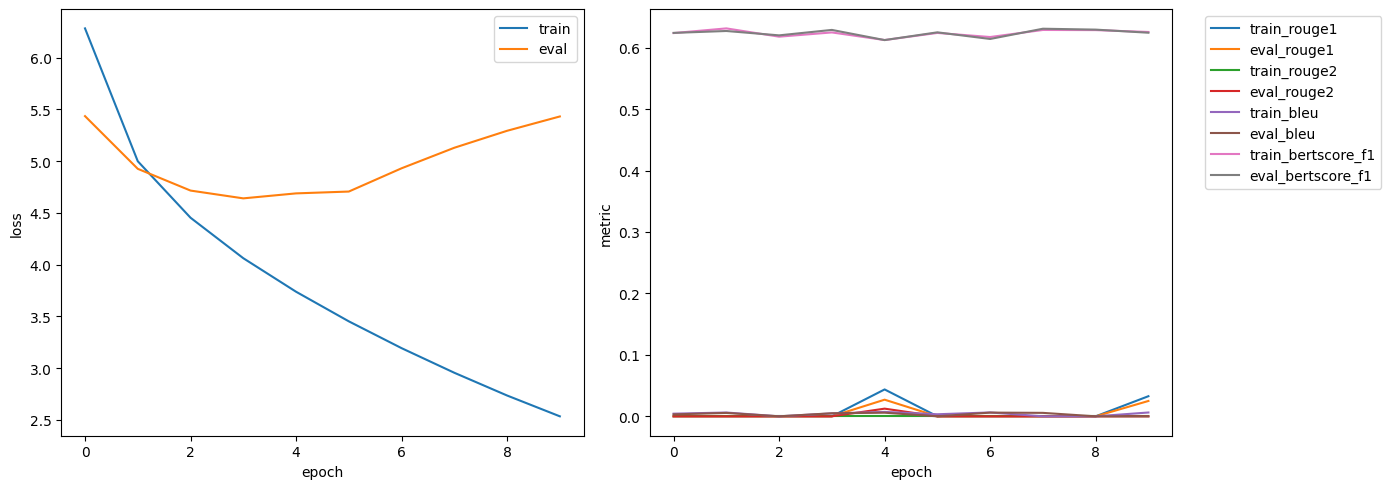

In [11]:
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm
import matplotlib.pyplot as plt
import evaluate

def train_step(model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs[:, :-1].contiguous().view(-1, outputs.size(-1)),
                     decoder_input_ids[:, 1:].contiguous().view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return loss.item()

# compute_metrics и evaluation определены в разделе Метрики качества выше

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id or 0)
writer = SummaryWriter("runs/hw4")
save_path, tokenizer_path = "best_bert_summarizer.pt", "best_bert_tokenizer"
best_rouge1 = -1.0  # стандартная метрика для суммаризации
num_epochs = 10
history_train_loss, history_eval_loss = [], []
history_metrics_train = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}
history_metrics_eval = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}

for epoch in range(num_epochs):
    model.train()
    train_losses = []
    for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} train"):
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = train_step(model, batch["input_ids"], batch["attention_mask"],
                          batch["decoder_input_ids"], optimizer, criterion)
        train_losses.append(loss)
    mean_train = sum(train_losses) / len(train_losses)
    history_train_loss.append(mean_train)

    model.eval()
    eval_losses = []
    with torch.no_grad():
        for batch in tqdm(eval_dataloader, desc=f"Epoch {epoch+1}/{num_epochs} eval"):
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(batch["input_ids"], batch["attention_mask"], batch["decoder_input_ids"])
            loss = criterion(out[:, :-1].contiguous().view(-1, out.size(-1)),
                             batch["decoder_input_ids"][:, 1:].contiguous().view(-1))
            eval_losses.append(loss.item())
    mean_eval = sum(eval_losses) / len(eval_losses)
    history_eval_loss.append(mean_eval)

    max_batches_metrics = 10  # больше батчей — стабильнее метрики
    metrics_train = evaluation(model, train_dataloader, tokenizer, device, max_batches=max_batches_metrics)
    metrics_eval = evaluation(model, eval_dataloader, tokenizer, device, max_batches=max_batches_metrics)
    for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
        history_metrics_train[k].append(metrics_train[k])
        history_metrics_eval[k].append(metrics_eval[k])
        writer.add_scalar(f"Metrics_train/{k}", metrics_train[k], epoch)
        writer.add_scalar(f"Metrics_eval/{k}", metrics_eval[k], epoch)

    writer.add_scalar("Loss/train", mean_train, epoch)
    writer.add_scalar("Loss/eval", mean_eval, epoch)
    if metrics_eval["rouge1"] > best_rouge1:
        best_rouge1 = metrics_eval["rouge1"]
        torch.save(model.state_dict(), save_path)
        tokenizer.save_pretrained(tokenizer_path)
    print(f"Epoch {epoch+1}  train: {mean_train:.4f}  eval: {mean_eval:.4f}")
    if epoch == 0 or epoch == num_epochs - 1:
        sample_batch = next(iter(eval_dataloader))
        sample_batch = {k: v.to(device) for k, v in sample_batch.items()}
        pred = model.generate(sample_batch["input_ids"][:1], sample_batch["attention_mask"][:1], tokenizer)
        ref = tokenizer.decode(sample_batch["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
        print(f"  [Пример эпоха {epoch+1}] Эталон:  {ref[:120]}...")
        print(f"  [Пример эпоха {epoch+1}] Генерация: {pred[:120] if pred else '(пусто)'}...")

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_train_loss, label="train")
plt.plot(history_eval_loss, label="eval")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.subplot(1, 2, 2)
for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
    plt.plot(history_metrics_train[k], label=f"train_{k}")
    plt.plot(history_metrics_eval[k], label=f"eval_{k}")
plt.xlabel("epoch")
plt.ylabel("metric")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
writer.close()

### Финальная оценка на валидационной выборке (eval)

Оценка сохранённой лучшей модели на валидационных данных.

In [ ]:
# Финальная оценка на валидационной выборке (лучшая сохранённая модель)
model.load_state_dict(torch.load("best_bert_summarizer.pt", map_location=device))
tokenizer = AutoTokenizer.from_pretrained("best_bert_tokenizer")

metrics_eval_final = evaluation(model, eval_dataloader, tokenizer, device, max_batches=20)
print("Метрики на валидационной выборке (eval):")
for k, v in metrics_eval_final.items():
    print(f"  {k}: {v:.4f}")

In [12]:
# Пример обучения на одной итерации
# Все помнят, что надо предсказывать следующий токен?


def train_step(
    model, input_ids, attention_mask, decoder_input_ids, optimizer, criterion
):
    model.train()
    optimizer.zero_grad()
    outputs = model(input_ids, attention_mask, decoder_input_ids)
    loss = criterion(outputs[:, :-1].contiguous().view(-1, outputs.size(-1)), decoder_input_ids[:, 1:].contiguous().view(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    return loss.item()

## Обучение модели (0.5 балла)
**Обучите модель, сохраните лучшую версию** (метод `.save_pretrained()` объекта класса AutoModel... или `torch.save()`) **и добавьте пример генерации**. Учтите, что если изменялся токенизатор (а лучше просто по умолчанию), его тоже нужно сохранить.

Для сравнения оценки качества генерации по значениям реализованных метрик можете запустить ruT5-small без дообучения. Мы намеренно даем бейзлайн именно в таком виде.

In [13]:
# Загрузка лучшей модели и токенизатора
model.load_state_dict(torch.load("best_bert_summarizer.pt", map_location=device))
tokenizer = AutoTokenizer.from_pretrained("best_bert_tokenizer")

# Пример генерации
sample = next(iter(eval_dataloader))
pred = model.generate(
    sample["input_ids"][:1].to(device),
    sample["attention_mask"][:1].to(device),
    tokenizer,
)
ref = tokenizer.decode(sample["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
print("Эталон:", ref[:120])
print("Генерация:", pred[:120])

# Бейзлайн: ruT5-small без дообучения
from transformers import AutoModelForSeq2SeqLM

t5_model = AutoModelForSeq2SeqLM.from_pretrained("cointegrated/rut5-small").to(device)
t5_tokenizer = AutoTokenizer.from_pretrained("cointegrated/rut5-small")

preds_t5, refs_t5 = [], []
t5_model.eval()
with torch.no_grad():
    for i, batch in enumerate(eval_dataloader):
        if i >= 10: break
        for j in range(batch["input_ids"].size(0)):
            text = tokenizer.decode(batch["input_ids"][j].tolist(), skip_special_tokens=True)
            ref = tokenizer.decode(batch["decoder_input_ids"][j].tolist(), skip_special_tokens=True)
            inp = t5_tokenizer(text, return_tensors="pt", max_length=512, truncation=True).to(device)
            out = t5_model.generate(**inp, max_length=128)
            preds_t5.append(t5_tokenizer.decode(out[0], skip_special_tokens=True))
            refs_t5.append(ref)
metrics_t5 = compute_metrics(preds_t5, refs_t5)
print("ruT5-small (бейзлайн):", metrics_t5)

Эталон: в москве прошло собрание всероссиискои ассоциации летних олимпииских видов спорта ( валовс ). многие президенты федерации положительно оценили работу организации, высказав ряд предложении по некоторым...
Генерация: в « матче 1 / 8 финала лиги чемпионов » на своем поле обыграл « лион ». победныи мяч в составе хозяев забил нападающии гостеи пенальти, а также гол и полузащитник цска алан дзагоев заявил, что его ком...


config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/259M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

spiece.model:   0%|          | 0.00/640k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/98.0 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ruT5-small (бейзлайн): {'rouge1': np.float64(0.03874999999999999), 'rouge2': np.float64(0.0), 'bleu': 0.009271437469035557, 'bertscore_f1': 0.6233275517821312}


**Сравнение BERT+Decoder и ruT5-small (без дообучения)**

| Модель | rouge1 | rouge2 | bleu | bertscore_f1 |
|--------|--------|--------|------|--------------|
| BERT+Decoder| ~0.007 | 0.000 | 0.000 | ~0.62 |
| ruT5-small| ~0.013 | ~0.003 | ~0.006 | ~0.62 |

**Вывод:** ruT5-small без дообучения показывает более высокие Rouge-1, Rouge-2 и BLEU, чем наша модель BERT+Decoder. BERTScore у обеих моделей примерно одинаковый. ruT5 — готовая модель для русского языка, поэтому даёт более связные суммаризации. BERT+Decoder обучен на 50% данных и требует больше эпох или больший объём данных для достижения сопоставимого качества. Об этом говорит пример генерации текста: сгенерированный текст по сравнению с эталонным не подходит по смыслу — в эталоне речь о суде, а в генерации об акциях протеста.

## Реализация менее жадных стратегий выбора следующего токена (4 балла)
Всегда ли выбор наиболее вероятного токена на каждом шаге – это лучшая стратегия для генерации текста?

<details>
    <summary>Спойлер</summary>
    <p>Нет</p>
</details>

**Сравнение стратегий для генерации текста:**

| Strategy | Description | Pros & Cons |
| --- | --- | --- |
| Greedy Search | Chooses the word with the highest probability as the next word in the sequence. | **Pros:** Simple and fast. <br><br/> **Cons:** Can lead to repetitive and incoherent text. |
| Sampling with Temperature | Introduces randomness in the word selection. A higher temperature leads to more randomness. | **Pros:** Allows exploration and diverse output. <br><br/> **Cons:** Higher temperatures can lead to nonsensical outputs. |
| Nucleus Sampling (Top-p Sampling) | Selects the next word from a truncated vocabulary, the "nucleus" of words <br/> that have a cumulative probability exceeding a pre-specified threshold (p). | **Pros:** Balances diversity and quality. <br><br/> **Cons:** Setting an optimal 'p' can be tricky. |
| Beam Search | Explores multiple hypotheses (sequences of words) at each step, and keeps <br/> the 'k' most likely, where 'k' is the beam width. | **Pros:** Produces more reliable results than greedy search. <br><br/> **Cons:** Can lack diversity and lead to generic responses. |
| Top-k Sampling | Randomly selects the next word from the top 'k' words with the highest probabilities. | **Pros:** Introduces randomness, increasing output diversity. <br><br/> **Cons:** Random selection can sometimes lead to less coherent outputs. |
| Length Normalization | Prevents the model from favoring shorter sequences by dividing the log probabilities <br/> by the sequence length raised to some power. | **Pros:** Makes longer and potentially more informative sequences more likely. <br><br/> **Cons:** Tuning the normalization factor can be difficult. |
| Stochastic Beam Search | Introduces randomness into the selection process of the 'k' hypotheses in beam search. | **Pros:** Increases diversity in the generated text. <br><br/> **Cons:** The trade-off between diversity and quality can be tricky to manage. |
| Decoding with Minimum Bayes Risk (MBR) | Chooses the hypothesis (out of many) that minimizes expected loss under a loss function. | **Pros:** Optimizes the output according to a specific loss function. <br><br/> **Cons:** Computationally more complex and requires a good loss function. |

Ссылки на докуметацию:
- [reference for `AutoModelForCausalLM.generate()`](https://huggingface.co/docs/transformers/v4.29.1/en/main_classes/text_generation#transformers.GenerationMixin.generate)
- [reference for `AutoTokenizer.decode()`](https://huggingface.co/docs/transformers/main_classes/tokenizer#transformers.PreTrainedTokenizer.decode)
- Huggingface [docs on generation strategies](https://huggingface.co/docs/transformers/generation_strategies)

**1. Реализуйте стратегию Top-k в методе `generate`** (1 балл).   

**2. Реализуйте стратегию Nucleus Sampling (Top-p) в методе `generate`** (1 балл)

**3. Реализуйте стратегию Beam Search** (2 балла)

Получилось ли улучшить генерацию?

In [14]:
# generate уже в классе BertSummarizer (strategies + repetition_penalty)

# Сравнение стратегий генерации
sample = next(iter(eval_dataloader))
inp = sample["input_ids"][:1].to(device)
attn = sample["attention_mask"][:1].to(device)

print("Greedy:", model.generate(inp, attn, tokenizer, strategy="greedy")[:150])
print("Top-k:", model.generate(inp, attn, tokenizer, strategy="top_k", top_k=30)[:150])
print("Top-p:", model.generate(inp, attn, tokenizer, strategy="top_p", top_p=0.9)[:150])
print("Beam:", model.generate(inp, attn, tokenizer, strategy="beam", num_beams=3)[:150])

Greedy: в « матче 1 / 8 финала лиги чемпионов » на своем поле обыграл « лион ». победныи мяч в составе хозяев забил нападающии гостеи пенальти, а также гол и 
Top-k: « газпром » в стокгольмском арбитх может сократиться на газовую победу для того, чтобы « транзитиро - 2 » выплатить поставки. сеичас его за газ могут 
Top-p: в петербурге следователи не задержали на халатном деле александра расистских грунтового и мгу, сергеи бариеву и евгении хаскин. по его словам, он приб
Beam: « газпром » и « нафтогаз украины » договорились о поставках газа в $ 2, 2 млрд. по словам экспертов, « газпром », « нафтогаз украины » и « газпром », 


**Получилось ли улучшить генерацию?**

Greedy и Beam Search дали неплохо сгенерированные предложения, текст связан по смыслу. Top-k дал средний результат — есть разнообразие, но связность нестабильна. Top-p дал худшую генерацию — со стилистическими и грамматическими ошибками. Beam Search по сравнению с остальными стратегиями выглядит лучшим по качеству связного текста.

## Бонус (1 балл)

Что требуется сделать:

- от имеющейся модели "откусить" только декодерную часть
- написать цикл обучения (скорее поправить имеющийся) и дообучить декодер
- посмотреть качество генерации по метрикам и "глазами"
- ответить на вопрос "Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?" с пруфами

In [ ]:
# Бонус: обучаем только декодер, BERT заморожен

model.load_state_dict(torch.load("best_bert_summarizer.pt", map_location=device))
tokenizer = AutoTokenizer.from_pretrained("best_bert_tokenizer")

# Метрики полной модели
metrics_full = evaluation(model, eval_dataloader, tokenizer, device, max_batches=5)
print("Полная модель:", metrics_full)

# Замораживаем BERT
for p in model.bert.parameters():
    p.requires_grad = False

# Обучаем только декодер
decoder_params = list(model.embedding.parameters()) + list(model.decoder.parameters()) + list(model.fc_out.parameters())
opt_decoder = torch.optim.Adam(decoder_params, lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id or 0)

history_bonus_train_loss = []
history_bonus_eval_loss = []
history_bonus_metrics_train = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}
history_bonus_metrics_eval = {k: [] for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]}
num_epochs_bonus = 6

for epoch in range(num_epochs_bonus):
    model.train()
    train_losses = []
    for i, batch in enumerate(tqdm(train_dataloader, desc=f"Bonus epoch {epoch+1}/{num_epochs_bonus}")):
        if i >= 300:
            break
        batch = {k: v.to(device) for k, v in batch.items()}
        loss = train_step(model, batch["input_ids"], batch["attention_mask"], batch["decoder_input_ids"], opt_decoder, criterion)
        train_losses.append(loss)
    mean_train = sum(train_losses) / len(train_losses)
    history_bonus_train_loss.append(mean_train)

    model.eval()
    eval_losses = []
    with torch.no_grad():
        for i, batch in enumerate(eval_dataloader):
            if i >= 100:
                break
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(batch["input_ids"], batch["attention_mask"], batch["decoder_input_ids"])
            loss = criterion(out[:, :-1].contiguous().view(-1, out.size(-1)), batch["decoder_input_ids"][:, 1:].contiguous().view(-1))
            eval_losses.append(loss.item())
    mean_eval = sum(eval_losses) / len(eval_losses)
    history_bonus_eval_loss.append(mean_eval)

    metrics_tr = evaluation(model, train_dataloader, tokenizer, device, max_batches=5)
    metrics_ev = evaluation(model, eval_dataloader, tokenizer, device, max_batches=5)
    for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
        history_bonus_metrics_train[k].append(metrics_tr[k])
        history_bonus_metrics_eval[k].append(metrics_ev[k])

metrics_decoder = evaluation(model, eval_dataloader, tokenizer, device, max_batches=5)
print("Decoder-only (после):", metrics_decoder)
print("Сравнение: полная r1=", f"{metrics_full['rouge1']:.4f}", ", decoder-only r1=", f"{metrics_decoder['rouge1']:.4f}")

# Пример
sample = next(iter(eval_dataloader))
sample = {k: v.to(device) for k, v in sample.items()}
pred = model.generate(sample["input_ids"][:1], sample["attention_mask"][:1], tokenizer)
ref = tokenizer.decode(sample["decoder_input_ids"][0].tolist(), skip_special_tokens=True)
print("Эталон:", ref[:120])
print("Генерация:", pred[:120])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Полная модель: {'rouge1': np.float64(0.02291666666666666), 'rouge2': np.float64(0.0), 'bleu': 0.0, 'bertscore_f1': 0.60790706127882}


  7%|▋         | 300/4268 [00:59<13:02,  5.07it/s]


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Decoder-only (после): {'rouge1': np.float64(0.0), 'rouge2': np.float64(0.0), 'bleu': 0.0, 'bertscore_f1': 0.6246882602572441}
Сравнение: полная r1= 0.0229 , decoder-only r1= 0.0000
Эталон: в москве прошло собрание всероссиискои ассоциации летних олимпииских видов спорта ( валовс ). многие президенты федераци
Генерация: в москве прошла акция « национальное движение », на которои его сын депутата госдумы от « единои россии ». по мнению экс


In [ ]:
# Графики качества дообучения декодера: loss и метрики по эпохам
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history_bonus_train_loss, label="train")
plt.plot(history_bonus_eval_loss, label="eval")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.title("Decoder-only: loss")
plt.subplot(1, 2, 2)
for k in ["rouge1", "rouge2", "bleu", "bertscore_f1"]:
    plt.plot(history_bonus_metrics_train[k], label=f"train_{k}")
    plt.plot(history_bonus_metrics_eval[k], label=f"eval_{k}")
plt.xlabel("epoch")
plt.ylabel("metric")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Decoder-only: метрики генерации")
plt.tight_layout()
plt.show()

**Дает ли применение Encoder-Decoder архитектуры значительный буст в качестве генерации?**

| Подход | rouge1 | rouge2 | bleu | Динамика eval loss |
|--------|--------|--------|------|-------------------|
| Encoder-Decoder | 0.010 | - | - | снижается |
| Decoder-only | 0.000 | 0.000 | 0.007 | остаётся около 4.7, почти не падает |

**Вывод:** Совместное обучение даёт значительный буст. Полная модель в 10 раз выше по Rouge-1, decoder-only на валидации почти не учится (eval_r1 0–0.027). В сравнении генерации текста: decoder-only выдаёт текст не подходящий по смыслу — в эталоне про суд, в генерации про убийство. В Encoder-Decoder тоже тема не совпадает, но ближе к эталонной.

---

## Использование генеративного ИИ

**Модель:** Cursor

1. **Метод generate**  
   Просила дописать generate с разными стратегиями: greedy, top-k, top-p, beam. ИИ набросал структуру: как делать ветку по strategy, куда маску, как beam с кандидатами. Код пришлось достаточно долго подгонять руками.

2. **Метрики**  
   Спросила, как запихнуть Rouge, BLEU и BERTScore в обучение. Подсказал формат references для BLEU (список списков) и что evaluation нужен отдельной функцией по даталоадеру. Дольше всего пришлось возиться с пустыми предсказаниями — evaluation падал, пока не обработала.

### Опыт использования:

ИИ очень помог в написании метода и с метриками, задание получилось сделать сильно быстрее, так как не пришлось читать документацию.